# Plotting results

This file is responsible for plotting the obtained results during the experiments.
Make sure to first run the `1 - Training classification models.ipynb` and `2 - Executing attack strategies.ipynb` files.

## Parameters

In [2]:
from utils.parameters import *

## Plot Classification Results

In [3]:
import json
import pandas as pd

with open(classification_results_filename, "r") as f:
    results = json.load(f)
    
classification_results = {}

for dataset_name, reports in results.items():
    fnn_df = pd.DataFrame([metric['weighted avg'] for metric in reports["fnn"]])
    snn_df = pd.DataFrame([metric['weighted avg'] for metric in reports["snn"]])
    
    # Calculate average and std for each metric
    fnn_df = fnn_df.agg(['mean', 'std'])
    snn_df = snn_df.agg(['mean', 'std'])
    
    reports["avg_fnn"] = fnn_df
    reports["avg_snn"] = snn_df
    
    classification_results[dataset_name] = {
        "fnn": {
            "accuracy": [metric['accuracy'] for metric in reports["fnn"]],
            "f1-score": [metric['weighted avg']['f1-score'] for metric in reports["fnn"]]
        },
        "snn": {
            "accuracy": [metric['accuracy'] for metric in reports["snn"]],
            "f1-score": [metric['weighted avg']['f1-score'] for metric in reports["snn"]]
        }
    }

### Classification models accuracy and F-1 score

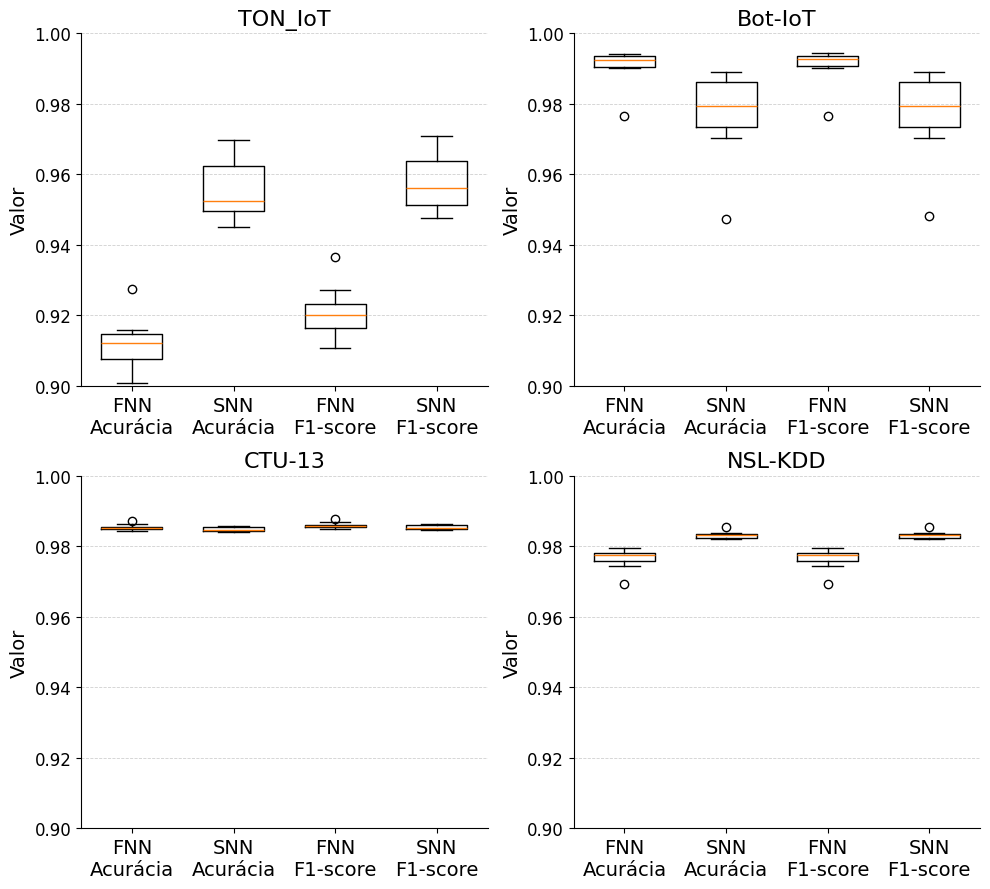

In [4]:
import matplotlib.pyplot as plt

n_datasets = len(classification_results)
n_rows = (n_datasets + 1) // 2

fig, axes = plt.subplots(
    n_rows,
    2,
    figsize=(10, 4.5 * n_rows),
    squeeze=False
)

for idx, (dataset_name, metrics) in enumerate(classification_results.items()):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]

    data = [
        metrics["fnn"]["accuracy"],
        metrics["snn"]["accuracy"],
        metrics["fnn"]["f1-score"],
        metrics["snn"]["f1-score"],
    ]

    ax.boxplot(
        data,
        tick_labels=['FNN\nAcurácia', 'SNN\nAcurácia', 'FNN\nF1-score', 'SNN\nF1-score'],
        widths=0.6,
        showfliers=True,
        patch_artist=False,
    )
    
    for label in ax.get_xticklabels():
        label.set_fontsize(14)

    # Axis formatting
    ax.set_ylabel('Valor', fontsize=14)
    ax.set_ylim(0.9, 1.0)
    
    for label in ax.get_yticklabels():
        label.set_fontsize(12)

    ax.grid(
        True,
        axis='y',
        linestyle='--',
        linewidth=0.6,
        alpha=0.6
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(dataset_names[dataset_name], fontsize=16)

# Hide unused subplots if n_datasets is odd
if n_datasets % 2 != 0:
    axes[-1, -1].axis('off')

plt.tight_layout()
plt.show()

# Save figure as pdf and png
fig.savefig("results/classification_results.pdf", format='pdf')
fig.savefig("results/classification_results.png", format='png', dpi=300)

## Plot Attack Results

In [5]:
import json

with open(attack_results_filename, "r") as f:
    results = json.load(f)
    
results_datasets = {}

for dataset_name, dataset_results in results.items():
    dataset_basename = dataset_name.split('_copy')[0]
    if dataset_basename not in results_datasets:
        results_datasets[dataset_basename] = {}
        
    for trial in dataset_results:
        for attack_network, res in trial.items():
            splits = attack_network.split('_')
            attack_type, network_type = splits[0], splits[1]
            
            if len(splits) > 2:
                attack_type += '_' + "_".join(splits[2:])
            
            if network_type not in results_datasets[dataset_basename]:
                results_datasets[dataset_basename][network_type] = {}
            if attack_type not in results_datasets[dataset_basename][network_type]:
                results_datasets[dataset_basename][network_type][attack_type] = []
                
            results_datasets[dataset_basename][network_type][attack_type].append(res)

### Scatter plot of accuracy X distance

Resultados de evasão - TON_IoT
Resultados de evasão - Bot-IoT
Resultados de evasão - NSL-KDD
Resultados de evasão - CTU-13


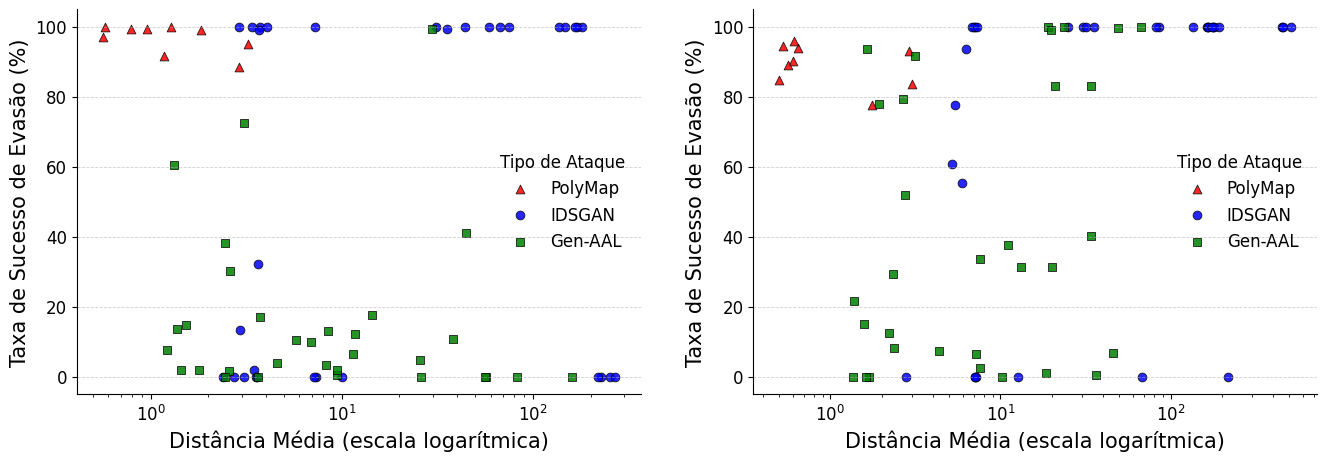

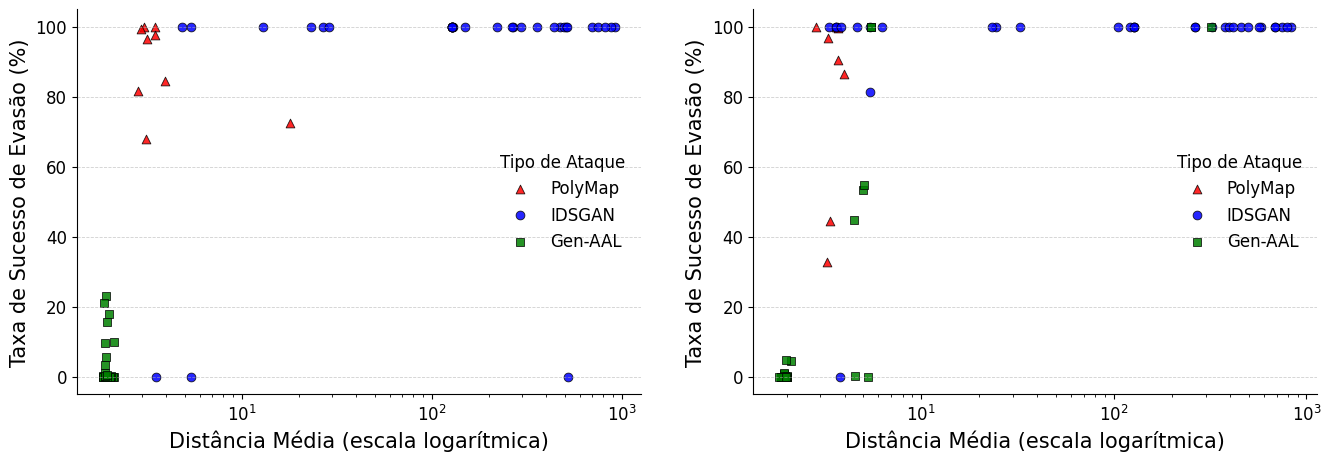

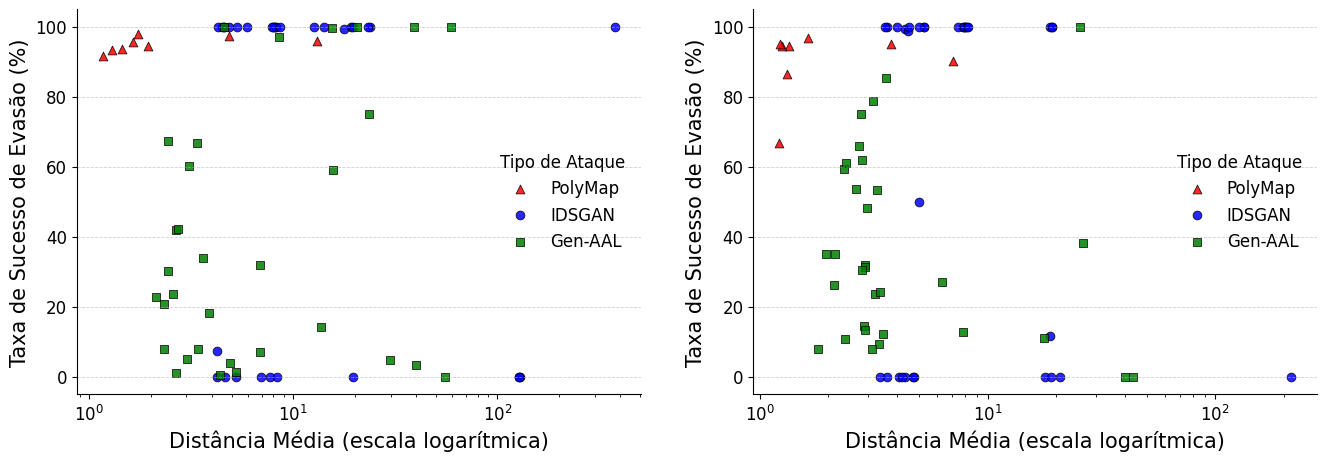

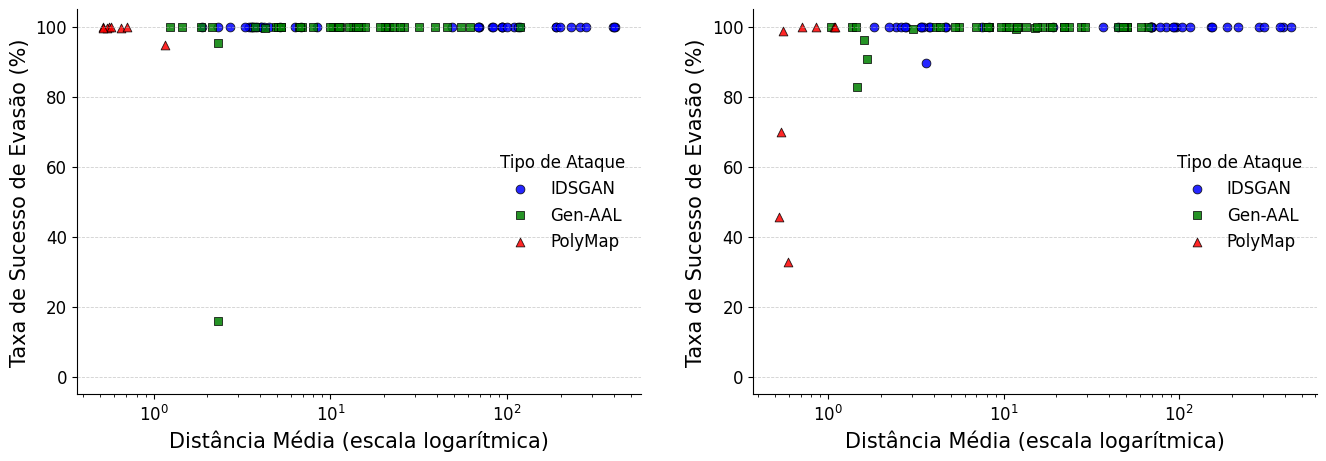

In [6]:
import matplotlib.pyplot as plt

lim_pad = 0.05

for dataset_name, dataset_results in results_datasets.items():
    n_network_types = len(dataset_results)
    
    fig, axes = plt.subplots(1, n_network_types, figsize=(8 * n_network_types, 5), squeeze=False)
    title = f'Resultados de evasão - {dataset_names.get(dataset_name, dataset_name.upper())}'
    print(title)
    # fig.suptitle(title, fontsize=16, y=0.92)
    
    for network_type, network_results in dataset_results.items():
        network_name = network_type.upper()
        
        # Accuracy vs Average Distance
        ax1 = axes[0, list(dataset_results.keys()).index(network_type)]

        for attack_type, attack_results in network_results.items():
            attack_name = attack_types.get(attack_type, attack_type.upper())

            accuracies = [res['accuracy'] * 100 for res in attack_results]
            distances = [res['average_distance'] for res in attack_results]

            # scatter plot with color mapping
            ax1.scatter(
                distances,
                accuracies,
                label=attack_name,
                marker=marker_map.get(attack_type, 'o'),
                color=color_map.get(attack_type, 'black'),
                s=40,                    
                edgecolors='black',
                linewidths=0.6,
                alpha=0.85
            )

        # Axis labels
        ax1.set_xlabel('Distância Média (escala logarítmica)')
        ax1.set_ylabel('Taxa de Sucesso de Evasão (%)')
        ax1.xaxis.label.set_size(15)
        ax1.yaxis.label.set_size(15)

        # Scaling and limits
        ax1.set_xscale('log')
        ax1.set_ylim(-lim_pad * 100, 100 + lim_pad * 100)
        
        for label in ax1.get_yticklabels():
            label.set_fontsize(12)
            
        for label in ax1.get_xticklabels():
            label.set_fontsize(12)

        ax1.grid(
            True,
            which='major',
            axis='y',
            linestyle='--',
            linewidth=0.6,
            alpha=0.6
        )

        ax1.legend(
            title='Tipo de Ataque',
            frameon=False,
            fontsize='large',
            title_fontsize='large',
            loc='center right'
        )

        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        
    fig.savefig(f"results/attack_results_{dataset_name}.pdf", format='pdf')
    fig.savefig(f"results/attack_results_{dataset_name}.png", format='png', dpi=300)

### Table with metrics from 3 best runs for each attack type

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

results_best = {}
n_best = 3

# For each dataset
for dataset_name, dataset_results in results_datasets.items():
    # For each network type
    results_best[dataset_name] = {}
    for network_type, network_results in dataset_results.items():
        # For each attack type
        best_metrics = {}
        for attack_type, attack_results in network_results.items():
            # Find the best n results based on accuracy, using the average distance as tiebreaker
            sorted_results = sorted(
                attack_results,
                key=lambda x: (x['accuracy'], -x['average_distance']),
                reverse=True
            )
            best_n = sorted_results[:n_best]
            accuracies = [res['accuracy'] for res in best_n]
            distances = [res['average_distance'] for res in best_n]
            best_metrics[attack_type] = {
                'accuracies': accuracies,
                'distances': distances
            }
        results_best[dataset_name][network_type] = best_metrics

# Convert to dataframe table
table_data = []
for dataset_name, dataset_results in results_best.items():
    for network_type, network_results in dataset_results.items():
        for attack_type, metrics in network_results.items():
            for i in range(n_best):
                table_data.append({
                    'Dataset': dataset_names.get(dataset_name, dataset_name.upper()),
                    'Network Type': network_type.upper(),
                    'Attack Type': attack_types.get(attack_type, attack_type.upper()),
                    'Accuracy': metrics['accuracies'][i],
                    'Average Distance': metrics['distances'][i]
                })
                
df = pd.DataFrame(table_data)

# Group results
grouped_df = df.groupby(['Network Type', 'Attack Type']).agg({
    'Accuracy': ['mean', 'std'],
    'Average Distance': ['mean', 'std']
}).reset_index()

# Flatten MultiIndex columns
grouped_df.columns = ['_'.join(col).strip('_') for col in grouped_df.columns.values]

# Change accuracy and distance to +- std format
grouped_df['Sucesso (%)'] = grouped_df.apply(
    lambda row: f"{row['Accuracy_mean']*100:.2f}% ± {row['Accuracy_std']*100:.2f}%",
    axis=1
)

grouped_df['Distância Média'] = grouped_df.apply(
    lambda row: f"{row['Average Distance_mean']:.4f} ± {row['Average Distance_std']:.4f}",
    axis=1
)

# Save as LaTeX table, grouped by Attack Type and Network Type
latex_table = grouped_df.pivot(
    index='Attack Type',
    columns='Network Type',
    values=['Sucesso (%)', 'Distância Média']
).to_latex(multicolumn=True, multirow=True, float_format=".4f")

with open("results/best_attack_results_table.tex", "w") as f:
    f.write(latex_table)

grouped_df

,Network Type,Attack Type,Accuracy_mean,Accuracy_std,Average Distance_mean,Average Distance_std,Sucesso (%),Distância Média
0,FNN,Gen-AAL,0.745033,0.349697,9.119787,13.074379,74.50% ± 34.97%,9.1198 ± 13.0744
1,FNN,IDSGAN,1.000000,0.000000,4.459921,2.901270,100.00% ± 0.00%,4.4599 ± 2.9013
2,FNN,PolyMap,0.990702,0.013467,2.810402,3.515094,99.07% ± 1.35%,2.8104 ± 3.5151
3,SNN,Gen-AAL,0.970089,0.071248,39.562131,89.748954,97.01% ± 7.12%,39.5621 ± 89.7490
4,SNN,IDSGAN,1.000000,0.000000,4.091473,1.850513,100.00% ± 0.00%,4.0915 ± 1.8505
5,SNN,PolyMap,0.975455,0.025686,1.762126,1.315153,97.55% ± 2.57%,1.7621 ± 1.3152


### Boxplot showing number of requests and number of malicious requests

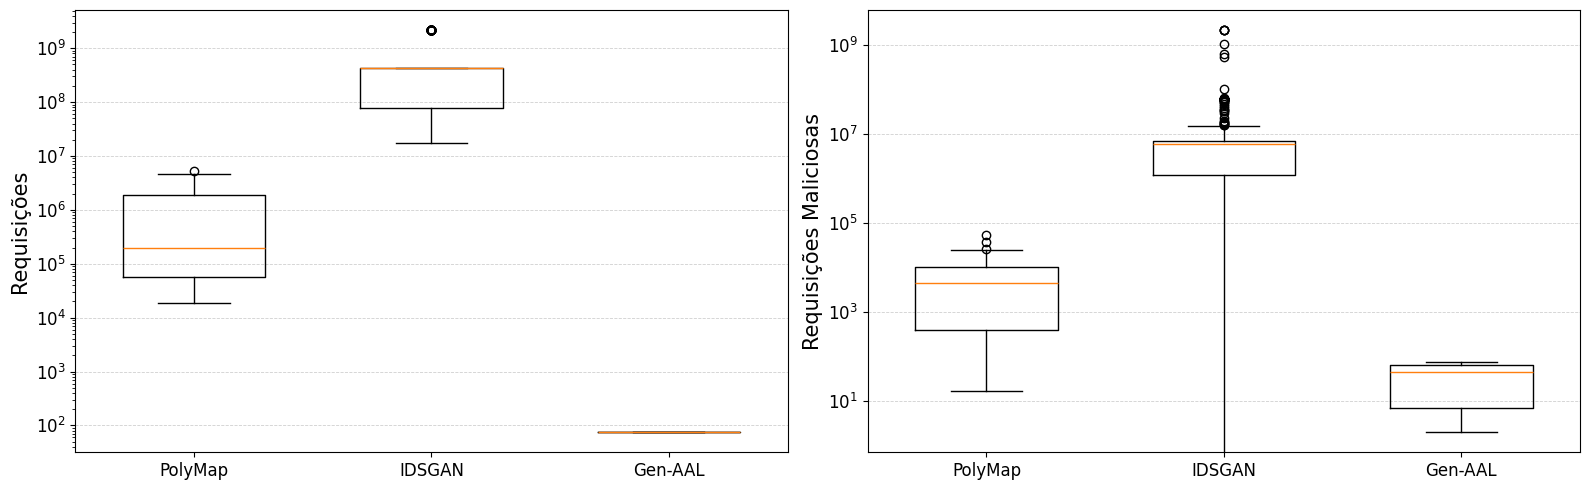

In [8]:
query_data = []

for dataset_name, dataset_results in results_datasets.items():
    for network_type, network_results in dataset_results.items():
        for attack_type, metrics in network_results.items():            
            for metric in metrics:
                m = {
                    "Attack Type": attack_types.get(attack_type, attack_type.upper()),
                    "Requisições": metric['query_stats']['n_queries'],
                    "Requisições Maliciosas": metric['query_stats']['malicious_queries'],
                }
                query_data.append(m)
            
# Create a pd table
df = pd.DataFrame(query_data)

# Plot boxplot of number of queries and number of malicious queries per attack type
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
attack_types_list = df['Attack Type'].unique()
for i, col in enumerate(['Requisições', 'Requisições Maliciosas']):
    ax = axes[i]
    data = [df[df['Attack Type'] == at][col] for at in attack_types_list]
    ax.boxplot(
        data,
        tick_labels=attack_types_list,
        widths=0.6,
        showfliers=True,
        patch_artist=False,
    )
    ax.set_ylabel(col, fontsize=15)
    ax.set_yscale('log')
    # ax.set_title(f'Distribuição de {col} por Tipo de Ataque', fontsize=16)
    ax.grid(
        True,
        axis='y',
        linestyle='--',
        linewidth=0.6,
        alpha=0.6
    )
    
    for label in ax.get_xticklabels():
        label.set_fontsize(12)
        
    for label in ax.get_yticklabels():
        label.set_fontsize(12)
        
plt.tight_layout()
plt.show()

fig.savefig("results/query_stats_boxplots.pdf", format='pdf')
fig.savefig("results/query_stats_boxplots.png", format='png', dpi=300)

### Boxplot showing evasion success rate and average distance

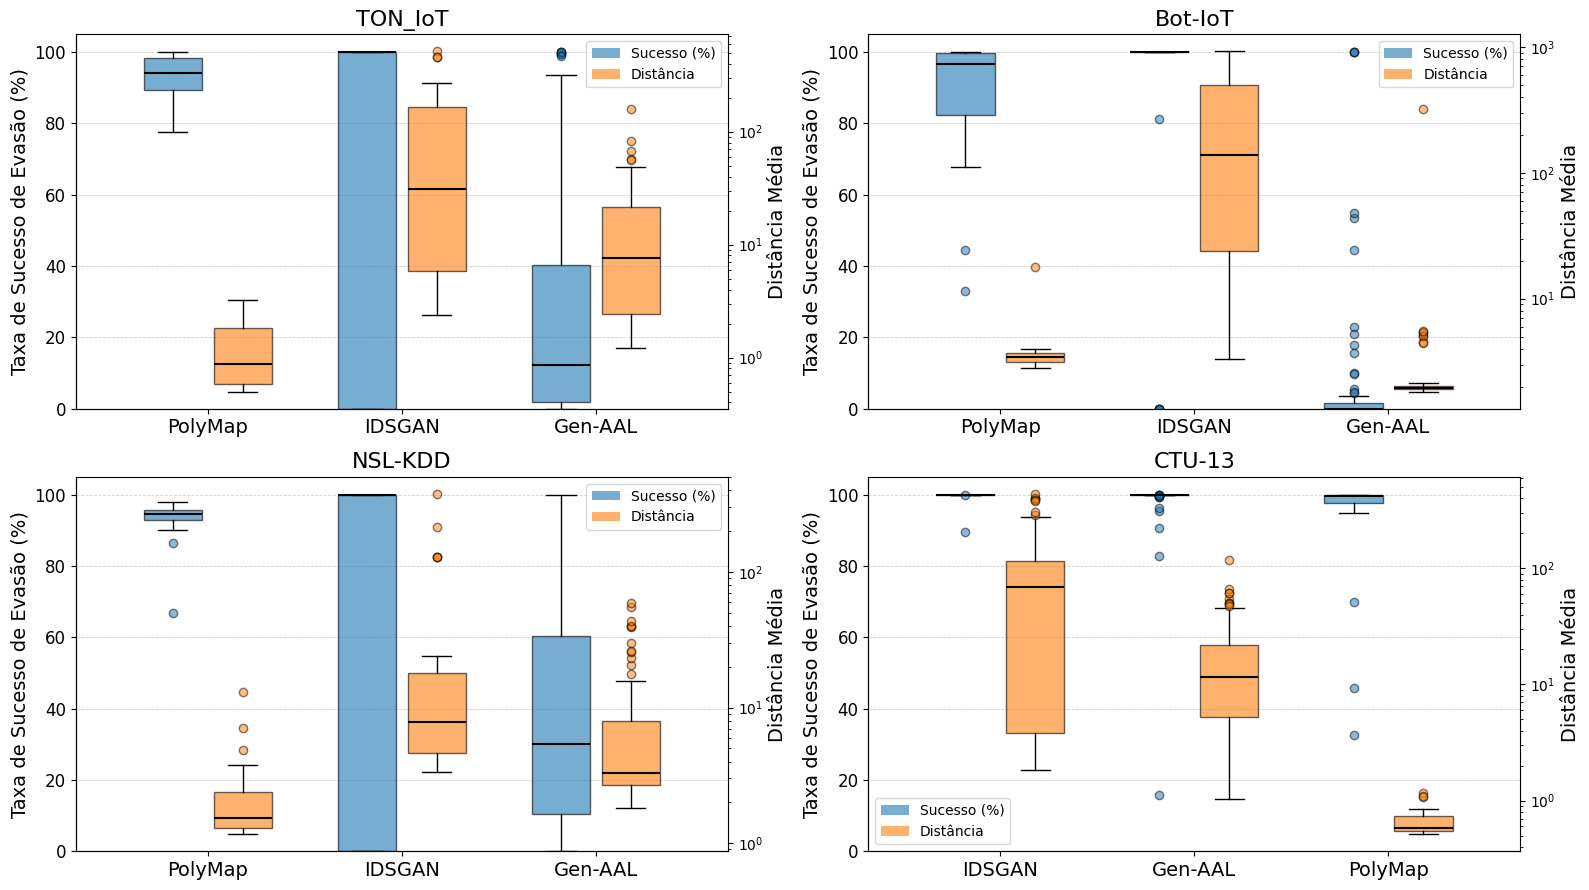

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

n_datasets = len(results_datasets)
n_rows = (n_datasets + 1) // 2

fig, axes = plt.subplots(
    n_rows,
    2,
    figsize=(16, 4.5 * n_rows),
    squeeze=False
)

for idx, (dataset_name, metrics) in enumerate(results_datasets.items()):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    network_types = list(metrics.keys())
    attacks = list(metrics[network_types[0]].keys())
    
    data_accuracy = []
    data_distance = []
    
    for attack in attacks:
        data_attack = {
            "accuracy": [],
            "distance": []
        }

        for network_type in network_types:
            data_attack["accuracy"].extend([ metric['accuracy'] * 100 for metric in metrics[network_type][attack]])
            data_attack["distance"].extend([ metric['average_distance'] for metric in metrics[network_type][attack]])
            
        data_accuracy.append(data_attack["accuracy"])
        data_distance.append(data_attack["distance"])
        
    x = np.arange(1, len(attacks) + 1)
    offset = 0.18
            
    bp_acc = ax.boxplot(
        data_accuracy,
        tick_labels=[attack_types.get(attack, attack.upper()) for attack in attacks],
        positions=x - offset,
        widths=0.3,
        showfliers=True,
        patch_artist=True,
        boxprops=dict(facecolor='tab:blue', alpha=0.6),
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black'),
        flierprops=dict(marker='o', markerfacecolor='tab:blue', alpha=0.5),
    )
    
    ax2 = ax.twinx()
    
    bp_dist = ax2.boxplot(
        data_distance,
        tick_labels=[attack_types.get(attack, attack.upper()) for attack in attacks],
        positions=x + offset,
        widths=0.3,
        showfliers=True,
        patch_artist=True,
        boxprops=dict(facecolor='tab:orange', alpha=0.6),
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black'),
        flierprops=dict(marker='o', markerfacecolor='tab:orange', alpha=0.5),
    )
    
    ax.set_xticks(x)
    ax.set_xticklabels(
        [attack_types.get(attack, attack.upper()) for attack in attacks],
        fontsize=14
    )
    
    ax.set_ylabel('Taxa de Sucesso de Evasão (%)', fontsize=14)
    ax2.set_ylabel('Distância Média', fontsize=14)

    # Axis formatting
    ax.set_ylim(0.0, 100.0 + 5)
    ax2.set_yscale('log')
    
    for label in ax.get_yticklabels():
        label.set_fontsize(12)

    ax.grid(
        True,
        axis='y',
        linestyle='--',
        linewidth=0.6,
        alpha=0.6
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(dataset_names[dataset_name], fontsize=16)
    
    legend_elements = [
        Patch(facecolor='tab:blue', label='Sucesso (%)', alpha=0.6),
        Patch(facecolor='tab:orange', label='Distância', alpha=0.6),
    ]

    ax.legend(
        handles=legend_elements,
        loc='best',
        fontsize=10
    )

# Hide unused subplots if n_datasets is odd
if n_datasets % 2 != 0:
    axes[-1, -1].axis('off')


plt.tight_layout()
plt.show()

# Save figure as pdf
fig.savefig("results/attack_results.pdf", format='pdf')
fig.savefig("results/attack_results.png", format='png', dpi=300)